In [1]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
print("sklearn OK, umap OK")

sklearn OK, umap OK


In [18]:
import os, io, time, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

# Config
N_IMAGES = 600            # how many images to embed (per-class sampling below)
IMAGES_PER_CLASS = 100    # 6 classes × 100 = 600 images
D_WORK = 10               # PCA-reduced dimension for search

# Paths
PROJECT = Path(r"C:\Users\shlok\projects\ddp-llm\scenery-search")
DATA = PROJECT / "data"
IMG_DIR = DATA / "intel_images"
IMG_DIR.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(0)

print(f"images dir: {IMG_DIR}")
print(f"target: {N_IMAGES} images, working dim: {D_WORK}")

device: cuda
images dir: C:\Users\shlok\projects\ddp-llm\scenery-search\data\intel_images
target: 600 images, working dim: 10


In [3]:
!kaggle --version


'kaggle' is not recognized as an internal or external command,
operable program or batch file.


found classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
  buildings: 2131 images
  forest: 2271 images
  glacier: 2404 images
  mountain: 2512 images
  sea: 2274 images
  street: 2382 images

sampled 600 images total
class distribution: {'buildings': 100, 'forest': 100, 'glacier': 100, 'mountain': 100, 'sea': 100, 'street': 100}

sample image: 14892.jpg
  size: (150, 150), mode: RGB, class: buildings


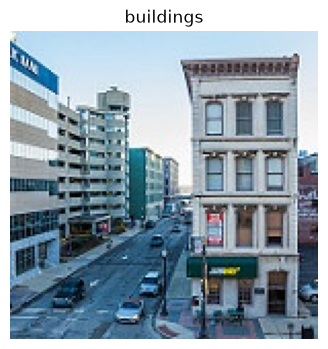

In [19]:
TRAIN_DIR = IMG_DIR / "seg_train" / "seg_train"

# verify structure
if not TRAIN_DIR.exists():
    print(f"ERROR: expected {TRAIN_DIR}")
    print(f"contents of {IMG_DIR}:")
    for p in IMG_DIR.iterdir():
        print(f"  {p.name}")
else:
    classes = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])
    print(f"found classes: {classes}")
    for cls in classes:
        n = len(list((TRAIN_DIR / cls).glob("*.jpg")))
        print(f"  {cls}: {n} images")

# sample IMAGES_PER_CLASS from each class
sample_paths = []
sample_labels = []
for cls in classes:
    cls_files = sorted((TRAIN_DIR / cls).glob("*.jpg"))
    picked_idx = rng.choice(len(cls_files), size=IMAGES_PER_CLASS, replace=False)
    for idx in picked_idx:
        sample_paths.append(cls_files[idx])
        sample_labels.append(cls)

print(f"\nsampled {len(sample_paths)} images total")
print(f"class distribution: {pd.Series(sample_labels).value_counts().to_dict()}")

# quick smoke test: load one, show it
img = Image.open(sample_paths[0])
print(f"\nsample image: {sample_paths[0].name}")
print(f"  size: {img.size}, mode: {img.mode}, class: {sample_labels[0]}")
plt.figure(figsize=(4, 4))
plt.imshow(img); plt.axis('off'); plt.title(sample_labels[0])
plt.show()

In [20]:
from transformers import CLIPProcessor, CLIPModel
from tqdm.auto import tqdm

MODEL_NAME = "openai/clip-vit-base-patch32"

print("loading CLIP...")
clip_model = CLIPModel.from_pretrained(MODEL_NAME).to(DEVICE)
clip_model.eval()
clip_processor = CLIPProcessor.from_pretrained(MODEL_NAME)
print(f"loaded {MODEL_NAME} on {DEVICE}")

# batch-embed all images
BATCH_SIZE = 32
embeddings = []

t0 = time.time()
with torch.no_grad():
    for start in tqdm(range(0, len(sample_paths), BATCH_SIZE), desc="embedding"):
        batch_paths = sample_paths[start:start + BATCH_SIZE]
        images = [Image.open(p).convert("RGB") for p in batch_paths]
        inputs = clip_processor(images=images, return_tensors="pt").to(DEVICE)
        feats = clip_model.get_image_features(**inputs)
        if hasattr(feats, "image_embeds"):
            feats = feats.image_embeds
        elif hasattr(feats, "pooler_output"):
            feats = feats.pooler_output
        feats = feats / feats.norm(dim=-1, keepdim=True)  # L2-normalize
        embeddings.append(feats.cpu().numpy())

E_raw = np.vstack(embeddings)
print(f"\nembedded {len(sample_paths)} images in {time.time()-t0:.1f}s")
print(f"E_raw shape: {E_raw.shape}")
print(f"embedding dim: {E_raw.shape[1]}")
print(f"unit-normalized: norms range [{np.linalg.norm(E_raw, axis=1).min():.4f}, {np.linalg.norm(E_raw, axis=1).max():.4f}]")

loading CLIP...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

loaded openai/clip-vit-base-patch32 on cuda


embedding:   0%|          | 0/19 [00:00<?, ?it/s]


embedded 600 images in 2.7s
E_raw shape: (600, 512)
embedding dim: 512
unit-normalized: norms range [1.0000, 1.0000]


In [21]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# PCA to working dimension
pca_work = PCA(n_components=D_WORK, random_state=0)
E_work = pca_work.fit_transform(E_raw)
var_explained = pca_work.explained_variance_ratio_.sum()
print(f"E_work shape: {E_work.shape}")
print(f"variance retained at D_work={D_WORK}: {var_explained:.1%}")

# 2D projections — three flavors
print("\ncomputing 2D projections...")
t0 = time.time()

pca_2d = PCA(n_components=2, random_state=0)
xy_pca = pca_2d.fit_transform(E_work)

xy_tsne = TSNE(n_components=2, random_state=0, init='pca',
               perplexity=30, max_iter=1000).fit_transform(E_work)

xy_umap = umap.UMAP(n_components=2, random_state=0, n_neighbors=15,
                    min_dist=0.1).fit_transform(E_work)

print(f"2D projections done in {time.time()-t0:.1f}s")
print(f"xy_pca:  {xy_pca.shape}")
print(f"xy_tsne: {xy_tsne.shape}")
print(f"xy_umap: {xy_umap.shape}")

XY = {"pca": xy_pca, "tsne": xy_tsne, "umap": xy_umap}

E_work shape: (600, 10)
variance retained at D_work=10: 47.5%

computing 2D projections...


C:\Users\shlok\projects\ddp-llm\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


2D projections done in 3.2s
xy_pca:  (600, 2)
xy_tsne: (600, 2)
xy_umap: (600, 2)


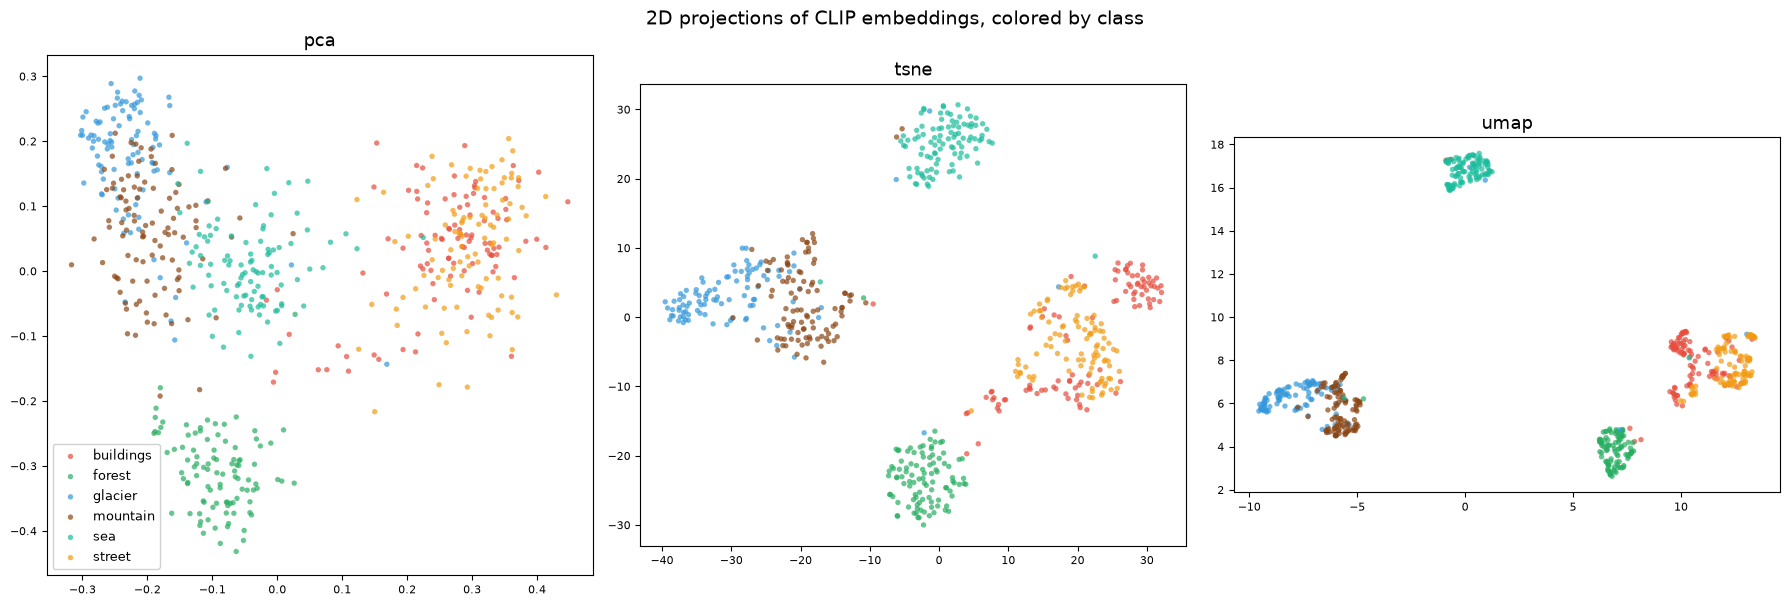

In [22]:
sample_labels_arr = np.array(sample_labels)
class_colors = {
    'buildings': '#e74c3c',
    'forest':    '#27ae60',
    'glacier':   '#3498db',
    'mountain':  '#8b4513',
    'sea':       '#1abc9c',
    'street':    '#f39c12',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, xy) in zip(axes, XY.items()):
    for cls in classes:
        mask = sample_labels_arr == cls
        ax.scatter(xy[mask, 0], xy[mask, 1], c=class_colors[cls],
                   label=cls, s=15, alpha=0.7, edgecolors='none')
    ax.set_title(name, fontsize=13)
    ax.set_aspect('equal')
    ax.tick_params(labelsize=8)
axes[0].legend(loc='best', fontsize=9, framealpha=0.9)
fig.suptitle("2D projections of CLIP embeddings, colored by class", fontsize=14)
fig.tight_layout()
plt.show()

loading thumbnails...
loaded 600 thumbnails


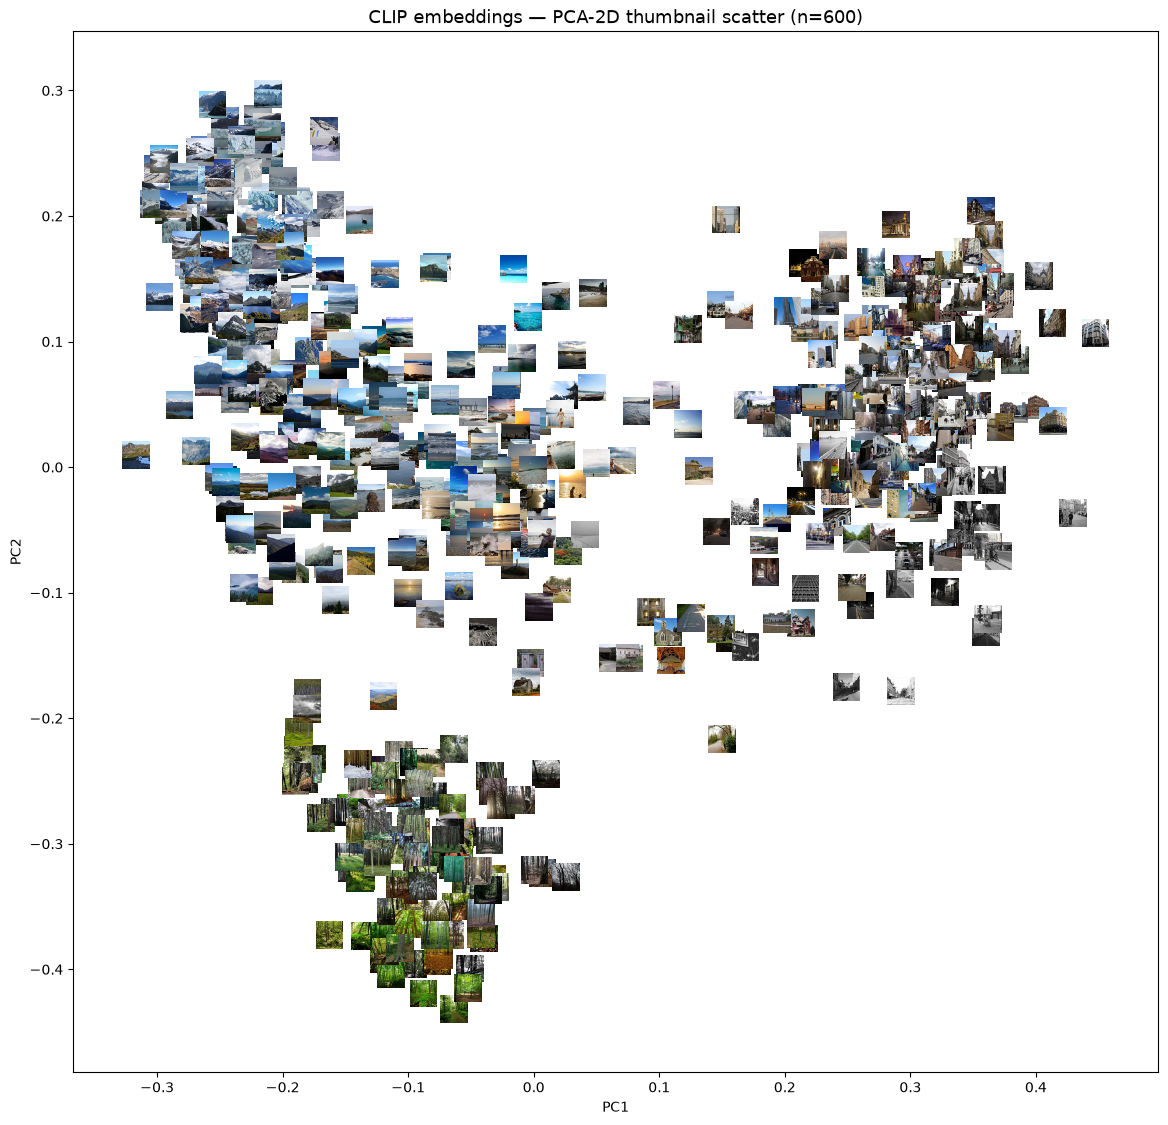

In [23]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

def load_thumb(path, size=(40, 40)):
    img = Image.open(path).convert("RGB").resize(size, Image.LANCZOS)
    return np.array(img)

# preload all thumbnails once
print("loading thumbnails...")
thumbs = [load_thumb(p) for p in sample_paths]
print(f"loaded {len(thumbs)} thumbnails")

# plot images at their PCA-2D positions
fig, ax = plt.subplots(figsize=(14, 14))
xy = XY["pca"]

for i in range(len(thumbs)):
    im = OffsetImage(thumbs[i], zoom=0.5)
    ab = AnnotationBbox(im, (xy[i, 0], xy[i, 1]), frameon=False, pad=0)
    ax.add_artist(ab)

# expand axes to fit
margin = 0.05
x_min, x_max = xy[:, 0].min(), xy[:, 0].max()
y_min, y_max = xy[:, 1].min(), xy[:, 1].max()
ax.set_xlim(x_min - margin, x_max + margin)
ax.set_ylim(y_min - margin, y_max + margin)
ax.set_aspect('equal')
ax.set_title(f"CLIP embeddings — PCA-2D thumbnail scatter (n={len(thumbs)})", fontsize=13)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.show()

In [24]:
N_TRIPLETS = 20
tri_rng = np.random.default_rng(42)

triplets = []
while len(triplets) < N_TRIPLETS:
    t, i, j = tri_rng.choice(len(sample_paths), 3, replace=False)
    triplets.append((int(t), int(i), int(j)))

def projection_answers(xy, triplets):
    """Which of i, j is Euclidean-closer to t in the given 2D space."""
    out = []
    for t, i, j in triplets:
        di = np.linalg.norm(xy[i] - xy[t])
        dj = np.linalg.norm(xy[j] - xy[t])
        out.append("i" if di < dj else "j")
    return out

# reference: agreement in full working-dim (E_work) — this is the "ground truth"
hi_dim_answers = projection_answers(E_work, triplets)

print(f"agreement of each 2D projection with the full {D_WORK}-d geometry:")
for name, xy in XY.items():
    proj_answers = projection_answers(xy, triplets)
    acc = np.mean([a == b for a, b in zip(hi_dim_answers, proj_answers)])
    print(f"  {name:5s} {acc:.0%}")

print(f"\nInterpretation:")
print(f"  Higher = more similarity structure survives the 50→2 squeeze.")
print(f"  Search runs in {D_WORK}-d anyway, but the 2D visualization is more honest if PCA-2D is high.")

agreement of each 2D projection with the full 10-d geometry:
  pca   80%
  tsne  80%
  umap  75%

Interpretation:
  Higher = more similarity structure survives the 50→2 squeeze.
  Search runs in 10-d anyway, but the 2D visualization is more honest if PCA-2D is high.


In [25]:
save_path = DATA / "scenery_embedding.npz"

np.savez(save_path,
         E_raw=E_raw,
         E_work=E_work,
         xy_pca=XY["pca"],
         xy_tsne=XY["tsne"],
         xy_umap=XY["umap"],
         pca_P=pca_2d.components_,      # (2, D_work) — for projecting belief mu/Sigma
         pca_mean=pca_2d.mean_,          # (D_work,)
         paths=np.array([str(p) for p in sample_paths]),
         labels=np.array(sample_labels))

print(f"saved to {save_path}")
print(f"file size: {save_path.stat().st_size / 1e6:.2f} MB")
print("\ncontents:")
data = np.load(save_path, allow_pickle=True)
for key in data.keys():
    arr = data[key]
    print(f"  {key:12s} shape={arr.shape} dtype={arr.dtype}")

saved to C:\Users\shlok\projects\ddp-llm\scenery-search\data\scenery_embedding.npz
file size: 1.54 MB

contents:
  E_raw        shape=(600, 512) dtype=float32
  E_work       shape=(600, 10) dtype=float32
  xy_pca       shape=(600, 2) dtype=float32
  xy_tsne      shape=(600, 2) dtype=float32
  xy_umap      shape=(600, 2) dtype=float32
  pca_P        shape=(2, 10) dtype=float32
  pca_mean     shape=(10,) dtype=float32
  paths        shape=(600,) dtype=<U104
  labels       shape=(600,) dtype=<U9


loading thumbnails...


NameError: name 'paths' is not defined